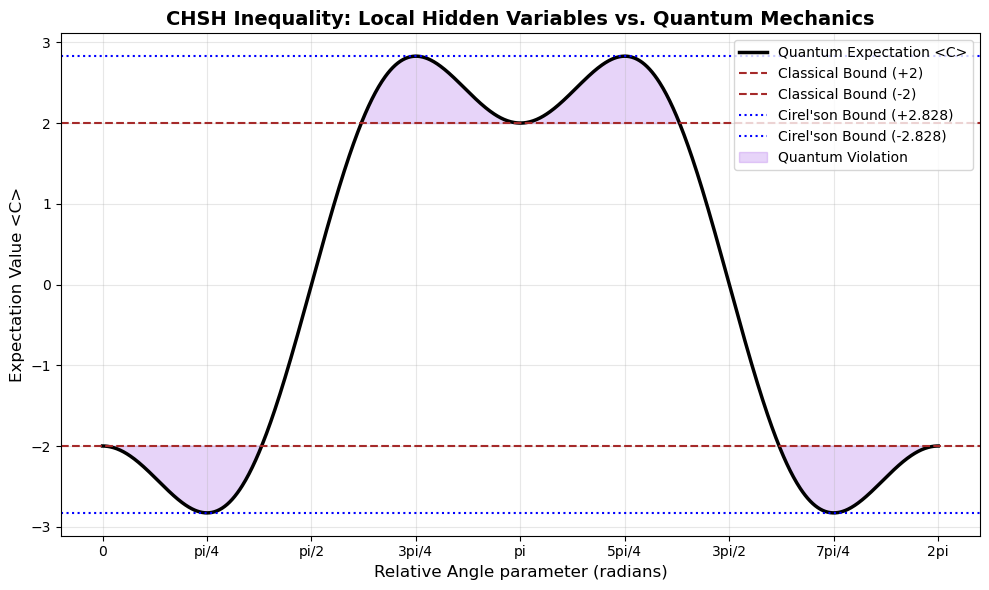

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# the relative angle theta
theta = np.linspace(0, 2 * np.pi, 1000)

# <C> = -3*cos(theta) + cos(3*theta)
C_exp = -3 * np.cos(theta) + np.cos(3 * theta)

# Defining the classical and Cirel'son bounds
classical_bound = 2
cirelson_bound = 2 * np.sqrt(2)

# plotting
plt.figure(figsize=(10, 6))

# Plotting the quantum expectation value curve
plt.plot(theta, C_exp, label="Quantum Expectation <C>", color="black", linewidth=2.5)

# Classical Bounds (+/- 2)
plt.axhline(y=classical_bound, color="brown", linestyle="--", linewidth=1.5, label="Classical Bound (+2)")
plt.axhline(y=-classical_bound, color="brown", linestyle="--", linewidth=1.5, label="Classical Bound (-2)")

# Cirel'son Bounds (+/- 2*sqrt(2))
plt.axhline(y=cirelson_bound, color="blue", linestyle=":", linewidth=1.5, label="Cirel'son Bound (+2.828)")
plt.axhline(y=-cirelson_bound, color="blue", linestyle=":", linewidth=1.5, label="Cirel'son Bound (-2.828)")

# Highlighting the regions where quantum mechanics violates local realism
plt.fill_between(theta, classical_bound, C_exp, where=(C_exp > classical_bound), color="blueviolet", alpha=0.2, 
                 label="Quantum Violation")
plt.fill_between(theta, -classical_bound, C_exp, where=(C_exp < -classical_bound), color="blueviolet", alpha=0.2)

plt.title("CHSH Inequality: Local Hidden Variables vs. Quantum Mechanics", fontsize=14, fontweight="bold")
plt.xlabel("Relative Angle parameter (radians)", fontsize=12)
plt.ylabel("Expectation Value <C>", fontsize=12)

# FIXED: Lowered the upper limit to 2.1 * np.pi so it generates exactly 9 ticks
plt.xticks(
    np.arange(0, 2.1 * np.pi, np.pi / 4),
    ['0', 'pi/4', 'pi/2', '3pi/4', 'pi', '5pi/4', '3pi/2', '7pi/4', '2pi']
)

plt.grid(True, alpha=0.3)
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()

# Because the script no longer crashes, it will successfully save the plot!
plt.savefig("CHSHsimu.png")
plt.show()

In [2]:
def chsh_monte_carlo(trials=100000):
    # The Referee distributes random bits x and y to Alice and Bob. 0 and 1 represent the two different measurement choices
    x = np.random.randint(0, 2, trials)
    y = np.random.randint(0, 2, trials)

    # CLASSICAL view (Local Hidden Variables)
    # Best deterministic strategy: Alice and Bob always output the same answer (e.g., 0).
    # Winning condition: a XOR b == x AND y. 
    # If they always output 0, a XOR b = 0. They win whenever x AND y == 0 (75% of the time).
    a_classical = np.zeros(trials)
    b_classical = np.zeros(trials)
    classical_wins = (a_classical != b_classical) == (x & y == 1)
    classical_win_rate = np.mean(classical_wins)

    # QUANTUM view (Entanglement)
    # Optimal measurement angles to saturate the Cirel'son bound:
    theta_A = np.where(x == 0, 0, np.pi/2)
    theta_B = np.where(y == 0, np.pi/4, -np.pi/4)

    # Quantum Mechanics dictates the probability of Alice and Bob getting the SAME measurement result (a XOR b == 0) when sharing an entangled state is:
    # P(same) = cos^2( (theta_A - theta_B) / 2 )
    prob_same = np.cos((theta_A - theta_B) / 2)**2
    # probabilistic collapse of the wavefunction for each particle pair
    random_rolls = np.random.rand(trials)
    # If the random roll is less than prob_same, they got the same result (XOR = 0). Otherwise, they got different results (XOR = 1)
    a_xor_b_quantum = np.where(random_rolls < prob_same, 0, 1)
    quantum_wins = a_xor_b_quantum == (x & y)
    quantum_win_rate = np.mean(quantum_wins)

    print(f"--- CHSH Game Monte Carlo Simulation ({trials:,} trials) ---")
    print(f"Classical Win Rate: {classical_win_rate*100:.2f}% (Theoretical Limit: 75.00%)")
    print(f"Quantum Win Rate:   {quantum_win_rate*100:.2f}% (Theoretical Limit: 85.36%)")

chsh_monte_carlo()

--- CHSH Game Monte Carlo Simulation (100,000 trials) ---
Classical Win Rate: 75.11% (Theoretical Limit: 75.00%)
Quantum Win Rate:   85.27% (Theoretical Limit: 85.36%)
